# **Exploratory Data Analysis (EDA)**


In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


**Basic Data Analysis**

In [3]:
df.shape

(32581, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

The dataset contains 32,581 observations and 12 variables, including both numerical and categorical features.
The analysis shows the presence of missing values, particularly in person_emp_length and loan_int_rate

In [6]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


The descriptive statistics reveal high variability in features such as income and loan amount, suggesting the presence of potential outliers.

**Target Variable Distribution**

In [7]:
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

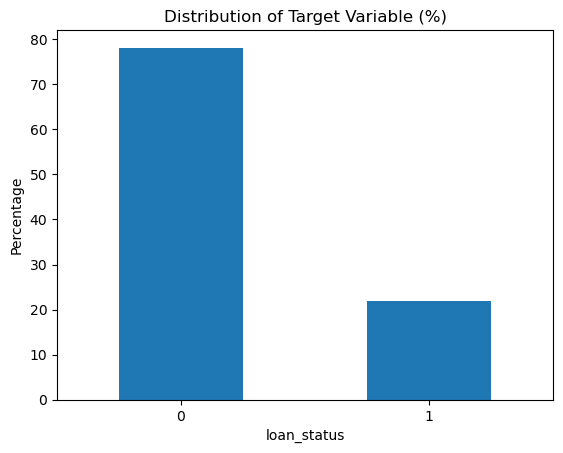

In [8]:
(df['loan_status'].value_counts(normalize=True) * 100).plot(kind='bar')

plt.title("Distribution of Target Variable (%)")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

The target variable loan_status is imbalanced, with approximately 78% non-default cases and 22% default cases

In [9]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols=num_cols.drop("loan_status")
num_cols

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')

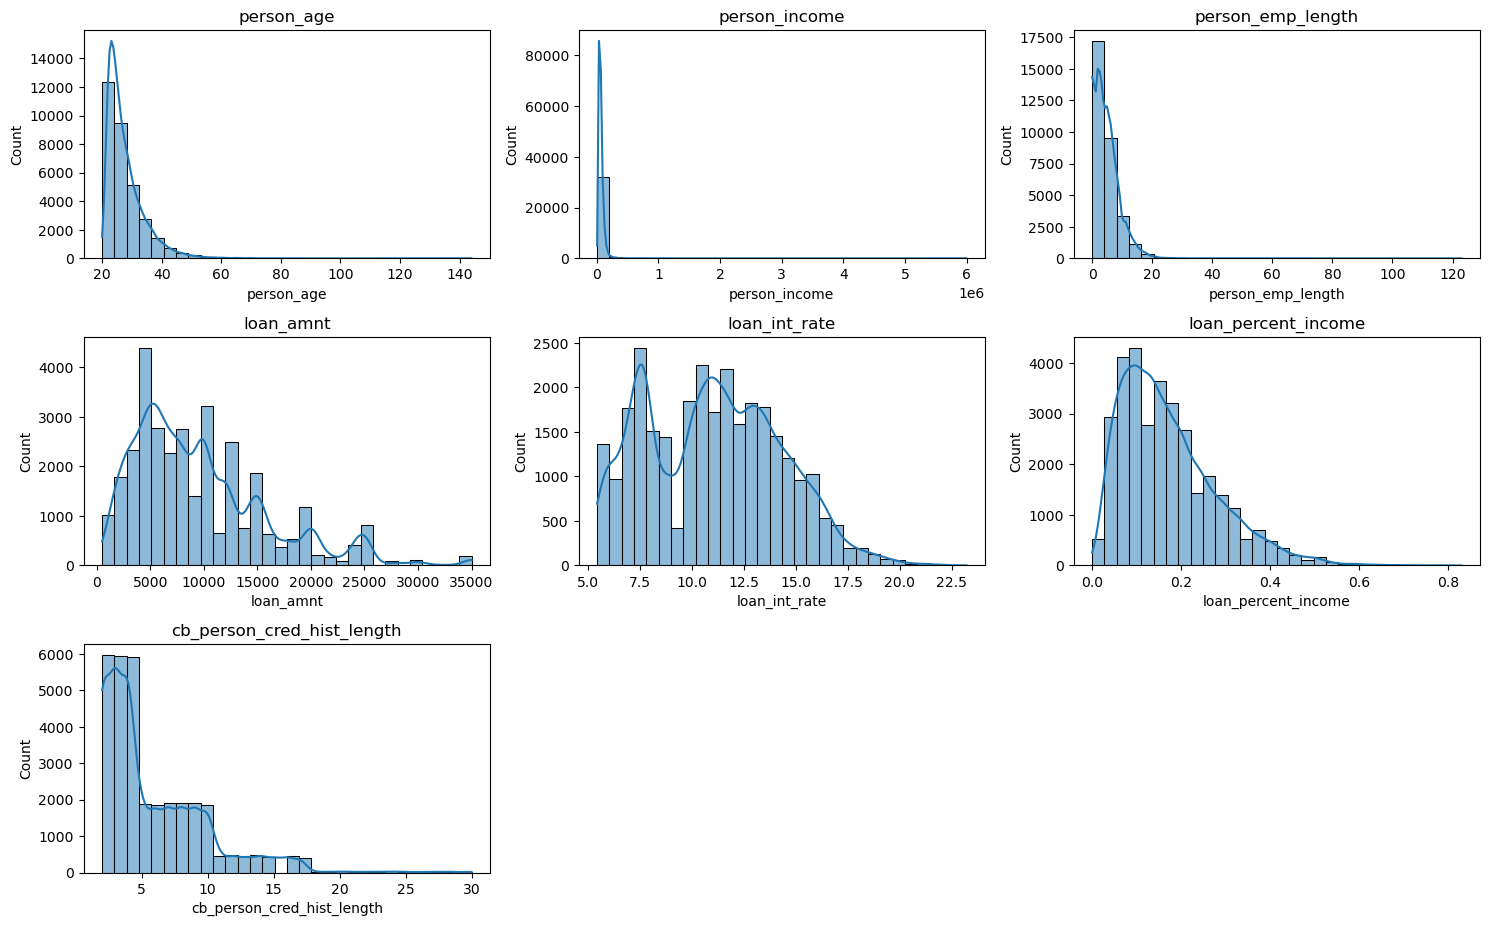

In [10]:
plt.figure(figsize=(15,12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

The distributions show that most numerical features are not normally distributed.

Several variables such as age, income, and loan amount are right-skewed, meaning most values are concentrated in lower ranges with a few extreme high values.

Employment length and credit history length are also concentrated at lower values, indicating that most borrowers have limited financial experience.

The loan-to-income ratio shows that most clients borrow a small portion of their income, while a few cases represent higher financial risk.

Overall, the dataset contains skewed distributions, outliers, and varying scales, which justifies the need for preprocessing before modeling.

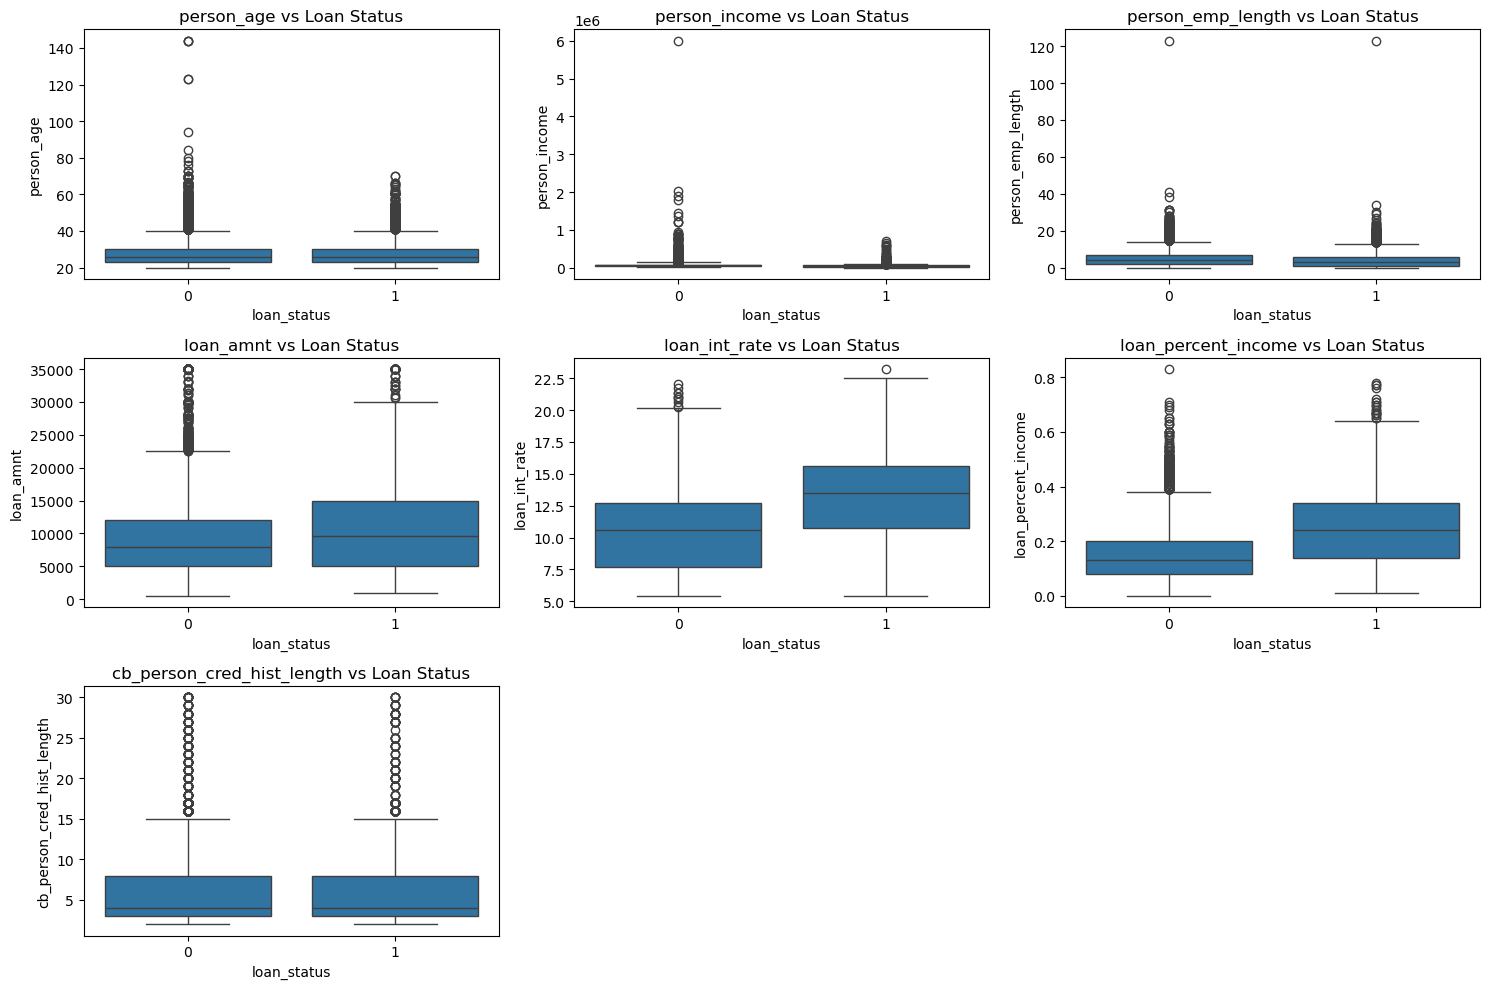

In [11]:
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='loan_status', y=col, data=df)
    plt.title(f"{col} vs Loan Status")

plt.tight_layout()
plt.show()

Variables such as age, income, employment length, and credit history show strong overlap between classes, indicating low discriminative power. These features also contain extreme outliers, which appear in both classes and are likely data anomalies rather than meaningful patterns.

Loan amount shows a slight tendency for higher values among default cases, but with significant overlap between distributions.

In contrast, interest rate and loan-to-income ratio show clearer separation between classes, with higher values associated with default cases.

Overall, most outliers are not strongly discriminative, but they help highlight risk patterns in specific variables.

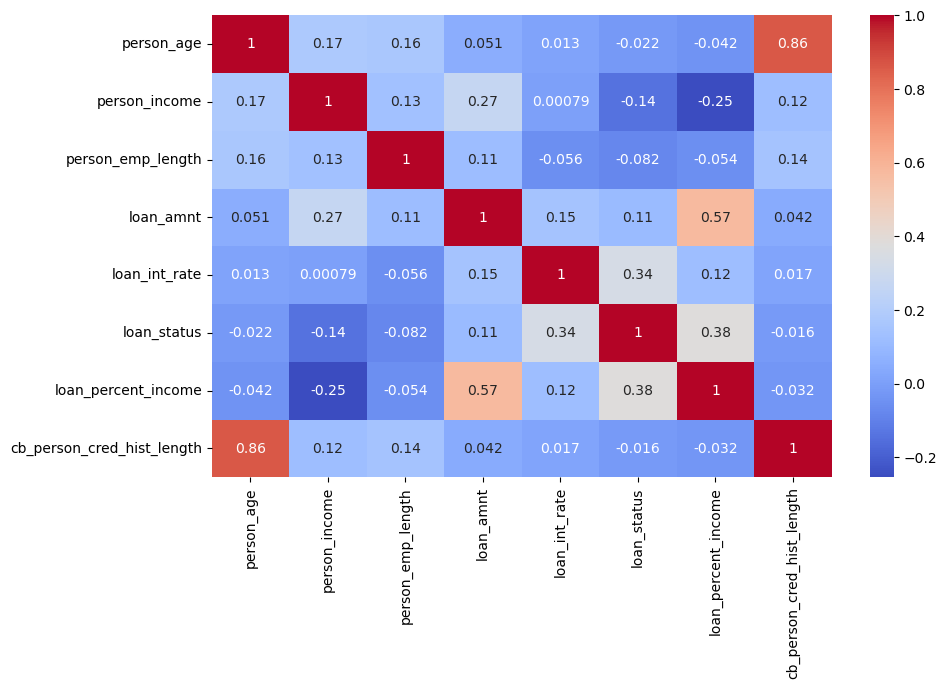

In [12]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

The correlation matrix helps analyze relationships between features and the target variable (loan_status), as well as dependencies among features.

Some variables show stronger correlation with the target, especially loan-to-income ratio and interest rate

Other variables such as age and employment length show weak correlation with the target.

There is also evidence of multicollinearity between some features:

* loan amount and loan-to-income ratio are strongly related
* age and credit history length are also correlated

This introduces redundancy, which can affect linear models, but tree-based models are less sensitive to this issue.

**Categorical Feature Analysis**

In [13]:
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')

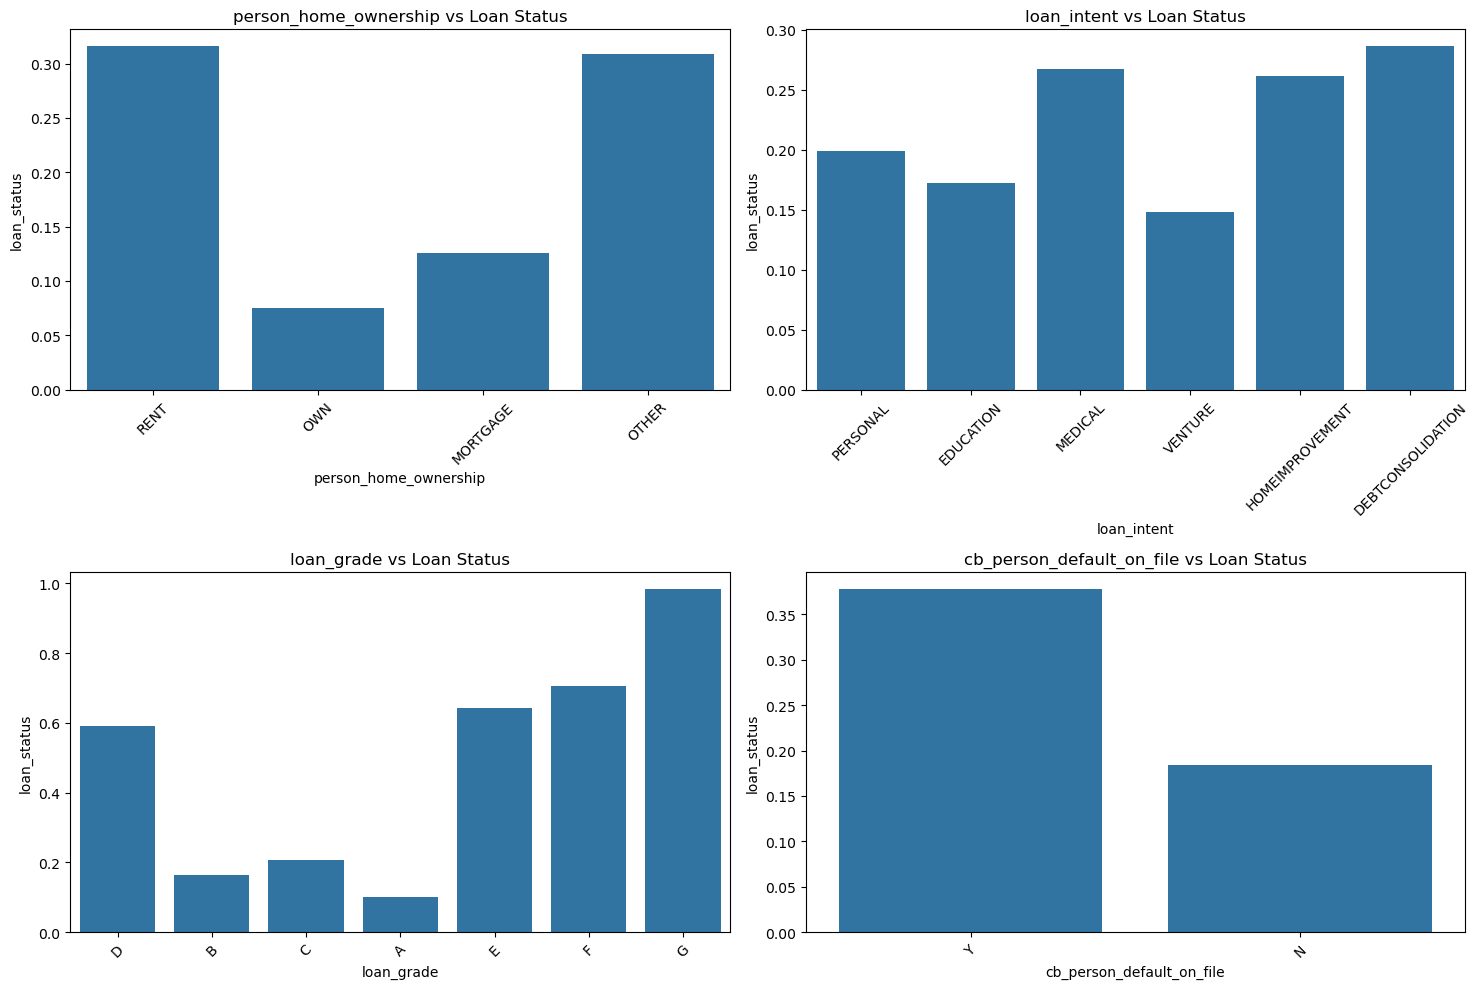

In [14]:
plt.figure(figsize=(15,10))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    sns.barplot(x=col, y='loan_status', data=df,errorbar=None)
    plt.title(f"{col} vs Loan Status")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The type of property (person_home_ownership) clearly influences repayment behavior.

Borrowers who own their homes (OWN) have the lowest default rates, while renters (RENT) and individuals in more unstable situations show significantly higher default rates.

This suggests that housing stability is an important indicator of financial stability.

The loan purpose (loan_intent) also shows important differences depending on the type of financing.

Loans for debt consolidation have the highest default rates, indicating that these borrowers are often already in financial difficulty.

On the other hand, loans related to investment or personal projects tend to show lower default rates.

The loan_grade variable shows the strongest separation between classes.

We observe a very clear increase in default risk as the credit grade worsens, ranging from low rates for grades A to very high rates for grades F and G.

This variable therefore appears to be one of the best indicators of credit risk.

Borrowers with a previous default history show a significantly higher risk of defaulting again.

This confirms that past behavior is a strong indicator of future credit behavior.

Overall, categorical variables provide important information about default risk, especially credit grade, loan purpose, and home ownership.

These variables will therefore be kept for the modeling phase, as they contain strong predictive signals.

**Final Conclusion of EDA**

The exploratory analysis provided important insights into the dataset.

The target variable is imbalanced, and several numerical features are skewed with extreme values.

Correlation analysis shows meaningful relationships between some variables and the target, especially loan-to-income ratio and interest rate, while also revealing multicollinearity between certain features.

Categorical variables such as loan grade, loan purpose, and home ownership provide strong predictive signals.

Overall, the dataset contains both predictive and non-informative features, which will guide the next steps: data cleaning, encoding, and preparation for modeling.